In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from phase_2.utils.paths import PROCESSED_DIR


In [2]:
SYMBOLS = [
    "SPY", "QQQ", "IWM",
    "AAPL", "MSFT", "NVDA",
    "XLU", "XLV", "XLP",
    "XLF", "XLE", "XLI",
]

data = {}

for sym in SYMBOLS:
    df = pd.read_parquet(PROCESSED_DIR / f"{sym.lower()}_daily.parquet")
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").reset_index(drop=True)
    df["year"] = df["date"].dt.year
    data[sym] = df

years = sorted(data["SPY"]["year"].unique())
years[:5], years[-5:]


([np.int32(2010),
  np.int32(2011),
  np.int32(2012),
  np.int32(2013),
  np.int32(2014)],
 [np.int32(2022),
  np.int32(2023),
  np.int32(2024),
  np.int32(2025),
  np.int32(2026)])

In [3]:
# Phase 2 strategies
from phase_2.scripts.strategies.trend.trend_strategy_v1 import run_trend_strategy_v1
from phase_2.scripts.strategies.meanrev.meanrev_strategy_v1 import run_meanrev_strategy_v1

# Phase 2 meta allocator & regime features
from phase_2.scripts.strategies.meta.meta_allocator_v1 import (
    build_regime_features,
    build_meta_raw_returns_param_v1,
)

# Phase 3 gates
from phase_3.strategies.meta.strategy_gates_v1 import apply_strategy_gates
# Portfolio plumbing
from phase_2.scripts.strategies.meta.risk_targeting_v1 import apply_vol_targeting
from phase_2.scripts.strategies.portfolio.portfolio_constructor_v1 import (
    align_asset_returns,
    compute_inverse_vol_weights,
    build_portfolio_raw_returns,
)
from phase_4.scripts.portfolio.risk_caps_v1 import (apply_all_risk_caps, SECTOR_MAP)
from phase_4.scripts.allocators.min_variance_v1 import solve_min_variance_weights


In [4]:
HARD_PARAMS_TIGHT = {
    "trend_mom60_min": 0.0,
    "trend_mom20_min": -0.005,
    "meanrev_mom20_max": -0.025,
    "meanrev_dd60_max": -0.03,
    "meanrev_vol20_max": 0.40,
}

In [5]:
def sharpe_ratio(x: pd.Series) -> float:
    x = x.values
    if np.std(x) == 0:
        return np.nan
    return np.sqrt(252) * np.mean(x) / np.std(x)

def max_drawdown_from_returns(r: pd.Series) -> float:
    eq = (1 + r).cumprod().values
    peak = np.maximum.accumulate(eq)
    dd = eq / peak - 1.0
    return dd.min()

In [6]:
# -------------------------------
# Risk contribution helper
# -------------------------------

def compute_risk_contributions(
    weights: pd.Series,
    cov: pd.DataFrame,
) -> pd.DataFrame:
    """
    Compute absolute and fractional risk contributions.

    Parameters
    ----------
    weights : pd.Series
        index = asset, values = weights (sum ~ 1).
    cov : pd.DataFrame
        Covariance matrix (assets x assets), typically annualized.

    Returns
    -------
    pd.DataFrame
        columns = [asset, weight, risk_contribution_frac]
    """
    # Align order
    cov = cov.loc[weights.index, weights.index]

    w = weights.values.reshape(-1, 1)    # (N, 1)
    Sigma = cov.values                   # (N, N)

    # Portfolio variance
    port_var = float(w.T @ Sigma @ w)
    if port_var <= 0 or np.isnan(port_var):
        # Degenerate case; just return weights with NaN RC
        return pd.DataFrame({
            "asset": weights.index,
            "weight": weights.values,
            "risk_contribution_frac": np.nan,
        })

    # Marginal risk contribution: Σ w
    mrc = Sigma @ w                      # (N, 1)

    # Absolute risk contribution: w_i * mrc_i
    rc_abs = (w * mrc).flatten()         # (N,)

    # Fractional contribution
    rc_frac = rc_abs / port_var          # (N,)

    return pd.DataFrame({
        "asset": weights.index,
        "weight": weights.values,
        "risk_contribution_frac": rc_frac,
    })


In [9]:
# -------------------------------
# Walkforward comparison:
# Baseline (inv-vol + hard caps) vs Min-Variance (strategic)
# -------------------------------

lookback_cov = 60  # days for covariance in training window

portfolio_hard = []
portfolio_minv = []
weights_hard_all = []
weights_minvar_all = []
risk_snapshots = []

for test_year in years:
    asset_daily = {}

    for sym in SYMBOLS:
        df_sym = data[sym]
        train_sym = df_sym[df_sym["year"] < test_year]
        test_sym  = df_sym[df_sym["year"] == test_year]

        # Require enough training and testing data
        if len(train_sym) < 500 or len(test_sym) < 60:
            continue

        # --- Strategy/meta returns on TEST only ---
        trend = run_trend_strategy_v1(test_sym, train_df=train_sym)
        meanr = run_meanrev_strategy_v1(test_sym)
        regime = build_regime_features(test_sym)
        trend, meanr = apply_strategy_gates(trend, meanr, regime)

        meta = build_meta_raw_returns_param_v1(trend, meanr, regime, HARD_PARAMS_TIGHT)
        meta["asset"] = sym
        meta["year"] = test_year
        asset_daily[sym] = meta[["date", "asset", "year", "meta_raw_ret"]]

    # If we couldn't build meta for all symbols, skip year
    if len(asset_daily) != len(SYMBOLS):
        continue

    # TEST-period wide meta returns
    ret_test = align_asset_returns(asset_daily)  # index=date, cols=assets, values=meta_raw_ret

    # -------------------------------
    # 1) Baseline: inverse-vol + hard caps (daily)
    # -------------------------------
    w_raw = compute_inverse_vol_weights(
        ret_test,
        lookback=20,
        max_weight=0.70,
    )

    w_hard = apply_all_risk_caps(
        w_raw,
        sector_map=SECTOR_MAP,
        max_weight_per_asset=0.20,
        max_sector_weight=0.40,
        min_assets_held=6,
    )

    # -------------------------------
    # 2) Min-variance: strategic OOS weights
    #    - Fit on pre-year asset risk (raw_ret), not on meta returns
    #    - Hold fixed for entire test year
    # -------------------------------
    # Build training wide returns using raw_ret from pre-year data
    frames = []
    for sym in SYMBOLS:
        df_sym = data[sym]
        train_sym = df_sym[df_sym["year"] < test_year].copy()

        # Ensure we have a return column; fallback if needed
        if "raw_ret" not in train_sym.columns:
            # Fallback to simple close-to-close if needed
            if "adj_close" in train_sym.columns:
                train_sym["raw_ret"] = train_sym["adj_close"].pct_change()
            elif "close" in train_sym.columns:
                train_sym["raw_ret"] = train_sym["close"].pct_change()
            else:
                raise ValueError(f"No return/price column found for {sym}")

        tmp = train_sym[["date", "raw_ret"]].copy()
        tmp["date"] = pd.to_datetime(tmp["date"])
        tmp = tmp.set_index("date").rename(columns={"raw_ret": sym})
        frames.append(tmp)

    ret_train_wide = pd.concat(frames, axis=1).sort_index()

    # Require enough non-NaN observations
    valid_train = ret_train_wide.dropna(how="all")
    if len(valid_train) < lookback_cov:
        continue

    cov_window = valid_train.iloc[-lookback_cov:]

    # Use your helper to compute min-var weights on training window
    # solve_min_variance_weights returns a DataFrame aligned with cov_window dates,
    # with the same weights repeated across those dates.
    w_train_df = solve_min_variance_weights(
        cov_window,
        lookback=lookback_cov,
        sector_map=SECTOR_MAP,
        max_weight_per_asset=0.20,
        max_sector_weight=0.40,
    )

    # Now expand those weights across the entire test period:
    w_minv_full = pd.DataFrame(
        np.repeat(w_train_df.values.reshape(1, -1), len(ret_test), axis=0),
        index=ret_test.index,
        columns=ret_test.columns,
    )

    # -------------------------------
    # 3) Build portfolios (test period)
    # -------------------------------
    port_raw_hard = build_portfolio_raw_returns(ret_test, w_hard)
    port_raw_minv = build_portfolio_raw_returns(ret_test, w_minv_full)

    vt_hard = apply_vol_targeting(
        port_raw_hard,
        target_vol_annual=0.10,
        lookback=20,
        max_leverage=1.0,
    )

    vt_minv = apply_vol_targeting(
        port_raw_minv,
        target_vol_annual=0.10,
        lookback=20,
        max_leverage=1.0,
    )

    portfolio_hard.append(pd.DataFrame({
        "date": port_raw_hard.index,
        "portfolio_ret": vt_hard["meta_ret"].values,
        "portfolio_lev": vt_hard["lev"].values,
        "year": test_year,
    }))

    portfolio_minv.append(pd.DataFrame({
        "date": port_raw_minv.index,
        "portfolio_ret": vt_minv["meta_ret"].values,
        "portfolio_lev": vt_minv["lev"].values,
        "year": test_year,
    }))

    # Store weights for possible inspection if needed
    w_hard_df = w_hard.copy()
    w_hard_df["date"] = w_hard_df.index
    w_hard_df["year"] = test_year
    weights_hard_all.append(w_hard_df.reset_index(drop=True))

    w_minv_df = w_minv_full.copy()
    w_minv_df["date"] = w_minv_full.index
    w_minv_df["year"] = test_year
    weights_minvar_all.append(w_minv_df.reset_index(drop=True))

    # -------------------------------
    # 4) Risk contribution snapshots (per year)
    #    Use realized test-year covariance for both methods
    # -------------------------------
    cov_year = ret_test.cov() * 252  # annualized realized covariance of meta returns

    # a) MinVar RC (fixed strategic weights)
    rc_minv = compute_risk_contributions(w_train_df, cov_year)
    rc_minv["year"] = test_year
    rc_minv["method"] = "minvar"
    risk_snapshots.append(rc_minv)

    # b) Baseline RC (use average weights across the year)
    avg_w_hard = w_hard.mean(axis=0)
    rc_hard = compute_risk_contributions(avg_w_hard, cov_year)
    rc_hard["year"] = test_year
    rc_hard["method"] = "hard_caps"
    risk_snapshots.append(rc_hard)


/var/folders/5x/hpfg2j9961g4st0gb95whvr80000gn/T/ipykernel_99475/1565228577.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  port_var = float(w.T @ Sigma @ w)
/var/folders/5x/hpfg2j9961g4st0gb95whvr80000gn/T/ipykernel_99475/1565228577.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  port_var = float(w.T @ Sigma @ w)
/var/folders/5x/hpfg2j9961g4st0gb95whvr80000gn/T/ipykernel_99475/1565228577.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  port_var = flo

In [10]:
# -------------------------------
# Combine walkforward results
# -------------------------------
portfolio_hard = pd.concat(portfolio_hard).sort_values("date").reset_index(drop=True)
portfolio_minv = pd.concat(portfolio_minv).sort_values("date").reset_index(drop=True)

weights_hard = pd.concat(weights_hard_all).sort_values("date").set_index("date")
weights_minv = pd.concat(weights_minvar_all).sort_values("date").set_index("date")

risk_df = pd.concat(risk_snapshots, ignore_index=True)

portfolio_hard.head(), portfolio_minv.head(), risk_df.head()


(        date  portfolio_ret  portfolio_lev  year
 0 2012-01-03            0.0            0.0  2012
 1 2012-01-04            0.0            0.0  2012
 2 2012-01-05            0.0            0.0  2012
 3 2012-01-06            0.0            0.0  2012
 4 2012-01-09            0.0            0.0  2012,
         date  portfolio_ret  portfolio_lev  year
 0 2012-01-03            0.0            0.0  2012
 1 2012-01-04            0.0            0.0  2012
 2 2012-01-05            0.0            0.0  2012
 3 2012-01-06            0.0            0.0  2012
 4 2012-01-09            0.0            0.0  2012,
   asset    weight  risk_contribution_frac  year  method
 0   SPY  0.083333                0.075652  2012  minvar
 1   QQQ  0.083333                0.106452  2012  minvar
 2   IWM  0.083333                0.101581  2012  minvar
 3  AAPL  0.083333                0.125450  2012  minvar
 4  MSFT  0.083333                0.070464  2012  minvar)

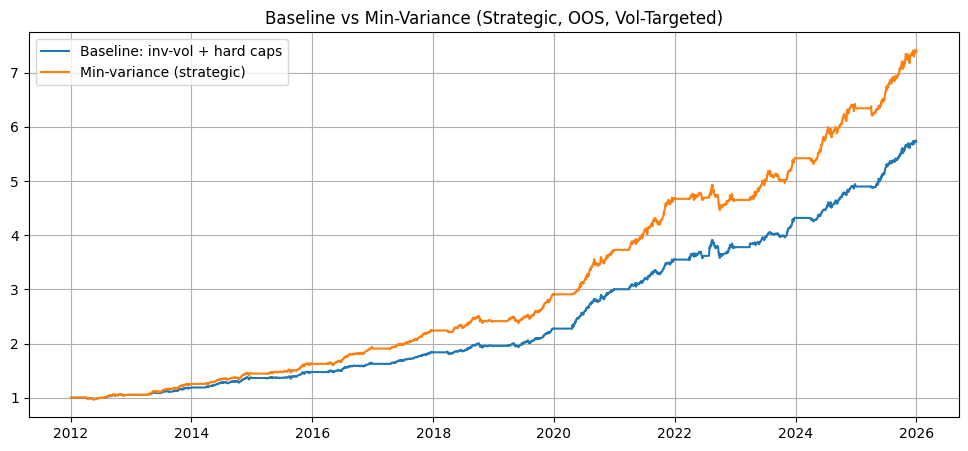

In [11]:
# -------------------------------
# Equity curves
# -------------------------------
eq_hard = (1 + portfolio_hard["portfolio_ret"]).cumprod()
eq_minv = (1 + portfolio_minv["portfolio_ret"]).cumprod()

plt.figure(figsize=(12, 5))
plt.plot(portfolio_hard["date"], eq_hard, label="Baseline: inv-vol + hard caps")
plt.plot(portfolio_minv["date"], eq_minv, label="Min-variance (strategic)")
plt.title("Baseline vs Min-Variance (Strategic, OOS, Vol-Targeted)")
plt.legend()
plt.grid(True)
plt.show()


In [12]:
# -------------------------------
# Yearly performance summary
# -------------------------------
rows = []

for y in sorted(portfolio_hard["year"].unique()):
    gb = portfolio_hard[portfolio_hard["year"] == y]
    gm = portfolio_minv[portfolio_minv["year"] == y]

    rows.append({
        "year": y,
        "sharpe_hard": sharpe_ratio(gb["portfolio_ret"]),
        "ret_hard": (1 + gb["portfolio_ret"]).prod() - 1,
        "mdd_hard": max_drawdown_from_returns(gb["portfolio_ret"]),
        "avgLev_hard": gb["portfolio_lev"].mean(),

        "sharpe_minv": sharpe_ratio(gm["portfolio_ret"]),
        "ret_minv": (1 + gm["portfolio_ret"]).prod() - 1,
        "mdd_minv": max_drawdown_from_returns(gm["portfolio_ret"]),
        "avgLev_minv": gm["portfolio_lev"].mean(),
    })

summary = pd.DataFrame(rows)
summary["sharpe_diff"] = summary["sharpe_minv"] - summary["sharpe_hard"]
summary["mdd_diff"] = summary["mdd_minv"] - summary["mdd_hard"]
summary


,year,sharpe_hard,ret_hard,mdd_hard,avgLev_hard,sharpe_minv,ret_minv,mdd_minv,avgLev_minv,sharpe_diff,mdd_diff
0,2012,1.315308,0.053409,-0.034168,0.924000,1.091973,0.053996,-0.044841,0.924000,-0.223335,-0.010674
1,2013,2.476063,0.128306,-0.021869,0.924603,3.065949,0.191091,-0.022964,0.924603,0.589887,-0.001095
2,2014,2.786122,0.147854,-0.031320,0.924603,2.531111,0.151309,-0.032228,0.924603,-0.255010,-0.000908
3,2015,1.491234,0.081220,-0.028230,0.903515,1.863953,0.124030,-0.036050,0.900645,0.372720,-0.007820
4,2016,2.277238,0.102250,-0.019313,0.924603,3.021674,0.174501,-0.027295,0.924603,0.744435,-0.007982
5,2017,3.785165,0.130715,-0.009913,0.924303,3.413978,0.173351,-0.013634,0.924303,-0.371188,-0.003721
6,2018,1.304034,0.064873,-0.039812,0.924284,1.342343,0.077962,-0.051916,0.915931,0.038309,-0.012105
7,2019,2.911053,0.162531,-0.035252,0.924603,2.977556,0.205195,-0.047608,0.915696,0.066503,-0.012356
8,2020,3.830966,0.319715,-0.028908,0.850823,3.468204,0.282256,-0.034328,0.871634,-0.362762,-0.005420
9,2021,3.141394,0.181964,-0.024376,0.924603,3.194496,0.252730,-0.028289,0.922906,0.053101,-0.003914


In [13]:
# -------------------------------
# Average risk contribution per asset & method
# -------------------------------
avg_rc = (
    risk_df
    .groupby(["method", "asset"])["risk_contribution_frac"]
    .mean()
    .reset_index()
    .sort_values(["method", "risk_contribution_frac"], ascending=[True, False])
)

avg_rc


,method,asset,risk_contribution_frac
3,hard_caps,NVDA,0.139053
4,hard_caps,QQQ,0.133480
2,hard_caps,MSFT,0.127898
5,hard_caps,SPY,0.118305
0,hard_caps,AAPL,0.109916
1,hard_caps,IWM,0.102112
8,hard_caps,XLI,0.061058
11,hard_caps,XLV,0.052751
7,hard_caps,XLF,0.050997
9,hard_caps,XLP,0.040381


In [14]:
# -------------------------------
# Herfindahl index of risk contributions by year & method
# H = sum_i (RC_i^2); lower = more diversified risk
# -------------------------------
conc = (
    risk_df
    .groupby(["year", "method"])
    .apply(lambda x: (x["risk_contribution_frac"] ** 2).sum())
    .rename("herfindahl_rc")
    .reset_index()
)

conc


/var/folders/5x/hpfg2j9961g4st0gb95whvr80000gn/T/ipykernel_99475/1796561888.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x["risk_contribution_frac"] ** 2).sum())


,year,method,herfindahl_rc
0,2012,hard_caps,0.098246
1,2012,minvar,0.089782
2,2013,hard_caps,0.094944
3,2013,minvar,0.088327
4,2014,hard_caps,0.095354
5,2014,minvar,0.089135
6,2015,hard_caps,0.106385
7,2015,minvar,0.098101
8,2016,hard_caps,0.109485
9,2016,minvar,0.120959


### Summary
Computing annual weights based on the portfolio variance of the last 60 days of the previous year seems naive, but this slow strategy uses a simple, stable principle with the same constaints as the previous baseline (hard capped) which generates greater returns over the test data. Future tactical computation (deriving weights with min varaince daily) will likely be implemented, although i could see that taking a long time to run when testing. 